# Practica 04: Analisis de datos exploratorio de python y Jypiter notebook en dataset de productos de amazon store

**Programa de estudios** Ingenieria de entornos virtuales y negocios digitales \
**Asignatura:** Analitica de datos digitales y negocios \
**Docente:** M.T.I. Marco A. Ramirez Hernández \
**Periodo:** Mayo-Agosto 2026 

### Unidad 2: Preparación de datos 

**Nombre del estudiante:** Samantha Salazar Fernández \
**Matricula:** 230004 \
**Grado y grpo:** 9A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;">🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)</h1>
<p style="color: #FFD700; text-align: center; font-size: 1.1em; margin-top: 10px;">Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos</p>
</div>

## Tabla de contenido 
|# | Sección | Descripcion |
|---|---|---|
|1|[Instalaciones & Carga de datos](#s1)|Librerias, cargas del cvs, primeros comandos de estructuras|
|2|[Diccionario de datos](#s2)|Explicacion de contenido de columnas y calcular el % porcentaje de datos|
|3|[Limpieza de datos](#s3)|Aplicaci+on de metdos basicos de limpieza (eliminacion de duplicados, agrupació y datos nulos)|

## 1. Instalaciones & Carga de Datos 🔌 <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Dataset:</b> Amazon India Listas de Prductos - 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y diponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [14]:
# =================================
# Section 1 -Setup & Data loading 
# =================================
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as pit
import matplotlib.ticker as sticker
import seaborn as sns 
import warnings 

from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'Pandas : {pd.__version__}')
print(f'Numpy : {np.__version__}')
print(f'Todas las librerias cargaron con exito!')

Pandas : 2.3.3
Numpy : 2.3.5
Todas las librerias cargaron con exito!


In [15]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f'Shape : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

Shape : (1445, 17)
Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de datos de dataframe <a id='s2'></a>

In [16]:
col_info = {
    'url': 'URL del producto en Amazon.in',
    'asin': 'Número estandarizado de identificación por Amazon (ID único)',
    'name': 'Nombre o título del producto',
    'overview': 'Breve reseña del producto (mayoría vacío [])',
    'price': 'Precio como string (ej. "1,600.00")',
    'currency': 'Código de divisa (todas en INR)',
    'availability': 'Texto del estado del stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URL de la imagen principal',
    'description': 'Descripción detallada y completa',
    'specification': 'Especificaciones técnicas',
    'primary_category': 'Categoría principal',
    'category_1': 'Categoría de nivel 1',
    'category_2': 'Categoría de nivel 2',
    'category_3': 'Categoría de nivel 3',
    'breadcrumbs': 'Ruta de navegación de categorías'
}

print('Diccionario de columnas')
print('-' * 90)

for col, desc in col_info.items():
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100

        print(
            f'{col:20s}| '
            f'{desc[:45]:45s}| '
            f'Missing: {missing_pct:.0f}%'
        )
    else:
        print(
            f'{col:20s}| '
            f'{desc[:45]:45s}| '
            f'NO EXISTE EN EL DATAFRAME'
        )

Diccionario de columnas
------------------------------------------------------------------------------------------
url                 | URL del producto en Amazon.in                | NO EXISTE EN EL DATAFRAME
asin                | Número estandarizado de identificación por Am| Missing: 0%
name                | Nombre o título del producto                 | Missing: 0%
overview            | Breve reseña del producto (mayoría vacío []) | Missing: 0%
price               | Precio como string (ej. "1,600.00")          | Missing: 24%
currency            | Código de divisa (todas en INR)              | Missing: 24%
availability        | Texto del estado del stock (Inventario)      | Missing: 33%
brand               | Nombre de la Marca/Autor                     | Missing: 1%
about_item          | Detalles/Especificaciones (mayoría faltante) | Missing: 92%
img_source          | URL de la imagen principal                   | Missing: 0%
description         | Descripción detallada y completa   

## 3.Limpieza de datos <a id='s3'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [17]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# Parse price
def clean_price(p):
    if pd.isna(p):
        return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# Standardise availability
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'
    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'
    if 'unavailable' in a:
        return 'Unavailable'
    if '1 to 3' in a:
        return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a:
        return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# Text length features
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# Duplicate check
dupes = df.duplicated(subset='asin').sum()

print(f'Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'Duplicate ASINs: {dupes}')
print(f'Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

Price parsed: 1,101 / 1,445 products
Duplicate ASINs: 8
Availability categories: {'In Stock': 608, 'Unknown': 478, 'Ships 1-3 weeks': 123, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


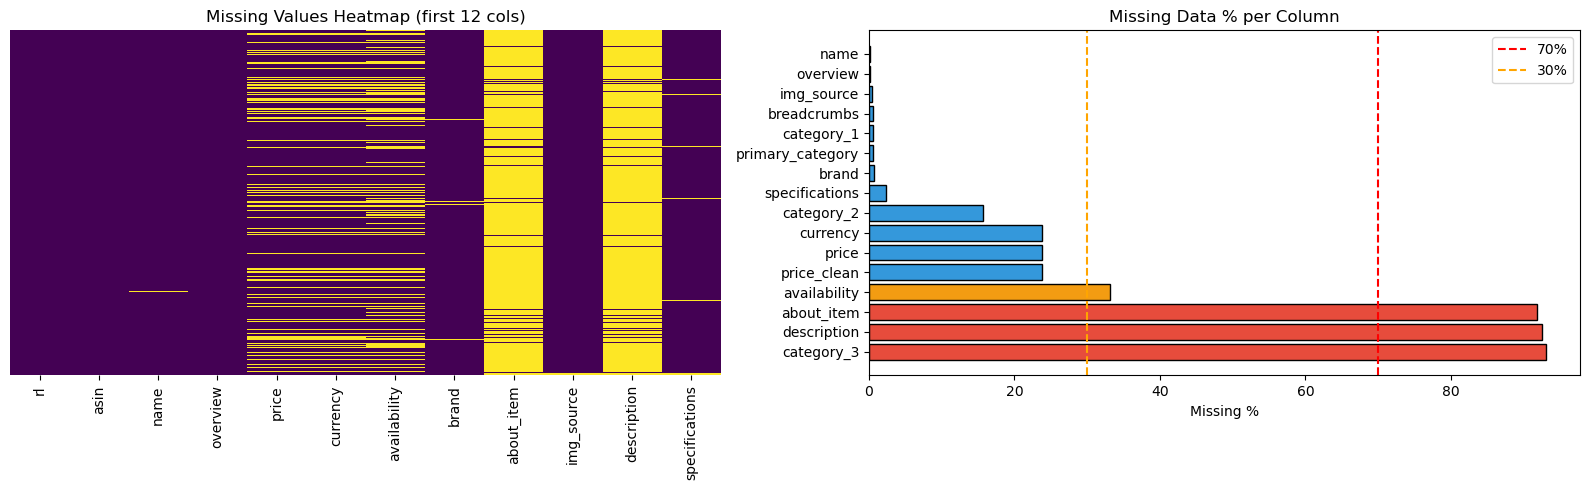

                  Missing Count  Missing Pct
category_3                 1346         93.1
description                1337         92.5
about_item                 1326         91.8
availability                478         33.1
price_clean                 344         23.8
price                       344         23.8
currency                    344         23.8
category_2                  227         15.7
specifications               35          2.4
brand                        10          0.7
primary_category              9          0.6
category_1                    9          0.6
breadcrumbs                   9          0.6
img_source                    6          0.4
overview                      3          0.2
name                          1          0.1


In [18]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

# Crear figura
fig, axes = pit.subplots(1, 2, figsize=(16, 5))

# Heatmap de valores faltantes
sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)

axes[0].set_title('Missing Values Heatmap (first 12 cols)')

# Filtrar columnas con valores faltantes
mv = missing[missing['Missing Pct'] > 0]

# Colores según porcentaje de faltantes
colors_mv = [
    '#e74c3c' if v > 70
    else '#F39c12' if v > 30
    else '#3498db'
    for v in mv['Missing Pct']
]

# Gráfico de barras
axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')

axes[1].legend()
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')

pit.tight_layout()
pit.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de caracteristicas (Feauturing Engineering)

<div style="background: #f0fff0; padding: 12px; border-left:4px solid #27ae68; border-radius: 5px; color: #0066cc;">
<b> Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que tambiénconsidera la ubicación, la antigüedad y
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [23]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     105
2_low        287
3_mid        320
4_premium    262
5_luxury     127
Unknown      344


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0
